# NSE Index Futures — Architecture Comparison (transfer claim, E3)

Trains all four architectures (**DeepLOB, MLPLOB, TLOB, MambaLOB**) from scratch on **NSE NIFTY /
BANKNIFTY index-futures** LOB, using the continuous front-month series (May→June, stitched across the
expiry roll). Event-time, **Scheme A** labels (alpha=1e-5, calibrated for index-futures price scale).

This is the **transfer claim**: the comparison is *between architectures on Indian data* — not against
published FI-2010 numbers (different market/data). Per LOBCAST/TLOB, expect F1 near baseline and decaying
with horizon; that is a finding. Every result is reported **against majority / always-stationary / random
baselines** so "barely above chance" can't masquerade as success.

> Needs a **GPU** (Mamba) and **AWS credentials** (to pull the Dhan parquet from S3). Reuses the repo's
> `load_nse` (front-month stitching + per-day lazy windowing) / `build_model` / `train`.


## 1. Runtime check

In [11]:
import torch, platform
print("Python:", platform.python_version(), "| Torch:", torch.__version__, "| CUDA:", torch.version.cuda)
assert torch.cuda.is_available(), "Enable a GPU runtime."
print("GPU:", torch.cuda.get_device_name(0))

Python: 3.12.13 | Torch: 2.10.0+cu128 | CUDA: 12.8
GPU: Tesla T4


## 2. Get the project code (reads the `GH_PAT` Colab secret)

In [12]:
import sys, subprocess, pathlib
REPO_URL = "https://github.com/rajjoseph48/nse-lob-capstone.git"
REPO_DIR = "nse-lob-capstone"
def _get_secret(name):
    # Kaggle -> Colab -> env var (inline: runs pre-clone, before nbenv is importable)
    try:
        from kaggle_secrets import UserSecretsClient
        v = UserSecretsClient().get_secret(name)
        if v:
            return v
    except Exception:
        pass
    try:
        from google.colab import userdata
        v = userdata.get(name)
        if v:
            return v
    except Exception:
        pass
    import os
    return os.environ.get(name, "")

GITHUB_TOKEN = _get_secret("GH_PAT")

def add_modeling(base):
    base = pathlib.Path(base)
    for cand in (base / "modeling", base):
        if (cand / "models.py").exists():
            sys.path.insert(0, str(cand.resolve()))
            return str(cand.resolve())
    return None

path = None
for c in (".", REPO_DIR, "/kaggle/working/" + REPO_DIR, "/content/" + REPO_DIR):
    path = add_modeling(c)
    if path:
        break
if not path:
    url = REPO_URL.replace("https://", f"https://{GITHUB_TOKEN}@") if GITHUB_TOKEN else REPO_URL
    subprocess.run(["git", "clone", "--depth", "1", url], check=True)
    path = add_modeling(REPO_DIR)
print("modeling/ on sys.path:", path)

modeling/ on sys.path: /kaggle/working/nse-lob-capstone/modeling


## 3. Install deps (Mamba kernel + boto3)
`mamba-ssm` / `causal-conv1d` compile CUDA extensions and import torch at build time, so they need
`--no-build-isolation` (else *"Getting requirements to build wheel did not run successfully"*). `boto3`
pulls the data from S3. If the kernel still won't build, MambaLOB falls back to pure-PyTorch (slower).

In [13]:
import subprocess, sys
def pipq(*pkgs): subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)
pipq("boto3")
pipq("ninja", "packaging", "setuptools", "wheel")
pipq("--no-build-isolation", "causal-conv1d")
pipq("--no-build-isolation", "mamba-ssm")
try:
    import mamba_ssm
    print("install step done | mamba-ssm", mamba_ssm.__version__)
except Exception as e:
    print("install step done | mamba-ssm NOT importable -> pure-PyTorch fallback:", repr(e))

install step done | mamba-ssm 2.3.2.post1


## 4. Download NSE Dhan data from S3

Needs AWS credentials. Store them as **Colab Secrets** `AWS_ACCESS_KEY_ID` and `AWS_SECRET_ACCESS_KEY`
(same way as `GH_PAT`), or paste below. Bucket `lob-capstone-data`, region **ap-south-2**. Downloads the
daily `lob_dhan_*.parquet` (~660 MB, skips empty roll-week files).

In [14]:
import os, boto3, pathlib

def _secret(name):
    # Kaggle -> Colab -> env var
    try:
        from kaggle_secrets import UserSecretsClient
        v = UserSecretsClient().get_secret(name)
        if v:
            return v
    except Exception:
        pass
    try:
        from google.colab import userdata
        v = userdata.get(name)
        if v:
            return v
    except Exception:
        pass
    return os.environ.get(name, "")

AWS_ACCESS_KEY_ID = ""       # or leave blank to use the Colab secret of the same name
AWS_SECRET_ACCESS_KEY = ""
os.environ["AWS_ACCESS_KEY_ID"] = AWS_ACCESS_KEY_ID or _secret("AWS_ACCESS_KEY_ID")
os.environ["AWS_SECRET_ACCESS_KEY"] = AWS_SECRET_ACCESS_KEY or _secret("AWS_SECRET_ACCESS_KEY")

BUCKET, PREFIX, REGION = "lob-capstone-data", "lob-data/dhan/", "ap-south-2"
DATA_DIR_NSE = "nse_data/dhan"
pathlib.Path(DATA_DIR_NSE).mkdir(parents=True, exist_ok=True)

s3 = boto3.client("s3", region_name=REGION)
objs = s3.list_objects_v2(Bucket=BUCKET, Prefix=PREFIX).get("Contents", [])
n = 0
for o in objs:
    if o["Size"] == 0:
        continue                      # skip empty roll-week files
    dst = os.path.join(DATA_DIR_NSE, o["Key"].split("/")[-1])
    if not os.path.exists(dst):
        s3.download_file(BUCKET, o["Key"], dst)
    n += 1
print(f"{n} parquet files in {DATA_DIR_NSE}:", sorted(os.listdir(DATA_DIR_NSE))[:3], "...")

25 parquet files in nse_data/dhan: ['lob_dhan_20260511.parquet', 'lob_dhan_20260512.parquet', 'lob_dhan_20260513.parquet'] ...


## 5. Metrics + naive baselines

In [15]:
import numpy as np, torch
from sklearn.metrics import (accuracy_score, f1_score, precision_recall_fscore_support,
                             matthews_corrcoef, confusion_matrix)
from fi2010_dataset import make_loader
from train import DEVICE

CLASS_NAMES = ["Down", "Stat", "Up"]

def collect_preds(model, ds, batch_size=256):
    model = model.to(DEVICE).eval()
    loader = make_loader(ds, batch_size=batch_size, shuffle=False)
    preds, labels = [], []
    with torch.no_grad():
        for X, y in loader:
            preds.append(model(X.to(DEVICE)).argmax(1).cpu().numpy())
            labels.append(y.numpy())
    return np.concatenate(preds), np.concatenate(labels)

def full_metrics(y_true, y_pred):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1, 2], zero_division=0)
    return {"accuracy": float(accuracy_score(y_true, y_pred)),
            "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
            "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
            "mcc": float(matthews_corrcoef(y_true, y_pred)),
            "per_class": {CLASS_NAMES[i]: {"precision": float(p[i]), "recall": float(r[i]),
                                           "f1": float(f[i])} for i in range(3)},
            "confusion": confusion_matrix(y_true, y_pred, labels=[0, 1, 2]).tolist()}

def naive_baselines(y_train, y_test):
    """Weighted-F1 of majority-class / always-stationary / class-freq-random predictors."""
    maj = int(np.bincount(y_train, minlength=3).argmax())
    wf1 = lambda yp: f1_score(y_test, yp, average="weighted", zero_division=0)
    rng = np.random.default_rng(0)
    probs = np.bincount(y_train, minlength=3) / len(y_train)
    return {"baseline_majority_wf1": round(wf1(np.full_like(y_test, maj)), 4),
            "baseline_stat_wf1": round(wf1(np.full_like(y_test, 1)), 4),
            "baseline_random_wf1": round(wf1(rng.choice(3, size=len(y_test), p=probs)), 4)}

## 6. NSE experiment runner
Trains one (model, symbol, horizon) on the stitched front-month series; records test metrics, the naive
baselines, and class balance. NSE overfits fast, so `patience=3`. Resumable CSV.

In [16]:
import time, json, pathlib, pandas as pd
from nse_dataset import load_nse
from models import build_model
from train import train, save_checkpoint

RESULTS_DIR = pathlib.Path("results"); RESULTS_DIR.mkdir(exist_ok=True)
CKPT_DIR = pathlib.Path("checkpoints/nse"); CKPT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_CSV = RESULTS_DIR / "nse_matrix.csv"
MODEL_LR = {"deeplob": 1e-3, "mlplob": 1e-3, "tlob": 1e-4, "mambalob": 3e-4}

from nbenv import s3_client, s3_put, s3_pull   # cross-timeout resumability
S3_BUCKET, S3_PREFIX = "lob-capstone-data", "reproduction/nse"
_s3 = s3_client()

def run_nse(model_name, symbol, horizon, label_scheme="A", seed=0,
            epochs=20, patience=3, batch_size=128, seq_len=100, save_to_csv=True):
    from stats import set_seed
    set_seed(seed)
    sch = "" if label_scheme.upper() == "A" else f"_{label_scheme.upper()}"
    tag = f"{model_name}_{symbol}_h{horizon}{sch}_s{seed}"
    lr = MODEL_LR.get(model_name, 1e-3)
    print("=" * 72); print(" ", tag, f"(lr={lr}, scheme={label_scheme})"); print("=" * 72)
    tr, vl, te = load_nse(symbol=symbol, horizon=horizon, seq_len=seq_len,
                          alpha=1e-5, label_scheme=label_scheme, data_dir=DATA_DIR_NSE)
    model = build_model(model_name, seq_len=seq_len, n_features=40)
    n_params = sum(p.numel() for p in model.parameters())
    t0 = time.time()
    hist = train(model, tr, vl, epochs=epochs, patience=patience, batch_size=batch_size, lr=lr, verbose=True)
    elapsed = time.time() - t0
    y_pred, y_true = collect_preds(model, te)
    mt = full_metrics(y_true, y_pred)
    bl = naive_baselines(tr.y.numpy(), y_true)
    row = {"model": model_name, "symbol": symbol, "horizon": horizon,
           "label_scheme": label_scheme.upper(), "seed": seed, "n_params": n_params,
           "best_epoch": hist["best_epoch"], "epochs_run": len(hist["val_f1"]),
           "best_val_f1": round(max(hist["val_f1"]), 4),
           "test_accuracy": round(mt["accuracy"], 4), "test_macro_f1": round(mt["macro_f1"], 4),
           "test_weighted_f1": round(mt["weighted_f1"], 4), "test_mcc": round(mt["mcc"], 4),
           **bl, "train_time_s": round(elapsed, 1)}
    if save_to_csv:
        ckpt = CKPT_DIR / f"{tag}.pt"; save_checkpoint(model, str(ckpt)); row["checkpoint"] = str(ckpt)
        df = pd.read_csv(RESULTS_CSV) if RESULTS_CSV.exists() else pd.DataFrame()
        df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
        df.to_csv(RESULTS_CSV, index=False)
        for _p in (RESULTS_CSV, ckpt):
            s3_put(_s3, _p, S3_BUCKET, S3_PREFIX)   # push this run now (timeout-safe)
    print(f"  -> macro_f1={mt['macro_f1']:.4f} weighted_f1={mt['weighted_f1']:.4f} "
          f"acc={mt['accuracy']:.4f} | baselines maj/stat/rand="
          f"{bl['baseline_majority_wf1']}/{bl['baseline_stat_wf1']}/{bl['baseline_random_wf1']} ({elapsed:.0f}s)")
    return row, mt, (y_true, y_pred)

## 7. Run the matrix

4 models × {NIFTY, BANKNIFTY} × horizons {10, 20, 50, 100} = 32 runs (Scheme A). Resumable — completed
`(model, symbol, horizon)` rows are skipped. Trim `MODELS` / `HORIZONS` to save time; it's deliberately
ordered cheap→expensive (deeplob, mlplob, tlob, mambalob).

In [17]:
MODELS = ["deeplob", "mlplob", "tlob", "mambalob"]
SYMBOLS = ["NIFTY", "BANKNIFTY"]
HORIZONS = [10, 20, 50, 100]
EPOCHS = 20

def _done_keys():
    if not RESULTS_CSV.exists():
        return set()
    d = pd.read_csv(RESULTS_CSV)
    for col, default in [("label_scheme", "A"), ("seed", 0)]:
        if col not in d.columns:
            d[col] = default
    return {(r.model, r.symbol, int(r.horizon), r.label_scheme, int(r.seed)) for r in d.itertuples()}

s3_pull(_s3, RESULTS_CSV, S3_BUCKET, S3_PREFIX)   # resume from prior sessions' progress
done = _done_keys()
for mdl in MODELS:
    for sym in SYMBOLS:
        for h in HORIZONS:
            if (mdl, sym, h, "A", 0) in done:
                print(f"skip {mdl} {sym} h{h} (in CSV)"); continue
            run_nse(mdl, sym, h, label_scheme="A", seed=0, epochs=EPOCHS)

pd.read_csv(RESULTS_CSV)

   pulled s3://lob-capstone-data/reproduction/nse/results/nse_matrix.csv (resuming)
skip deeplob NIFTY h10 (in CSV)
skip deeplob NIFTY h20 (in CSV)
skip deeplob NIFTY h50 (in CSV)
skip deeplob NIFTY h100 (in CSV)
skip deeplob BANKNIFTY h10 (in CSV)
skip deeplob BANKNIFTY h20 (in CSV)
skip deeplob BANKNIFTY h50 (in CSV)
skip deeplob BANKNIFTY h100 (in CSV)
skip mlplob NIFTY h10 (in CSV)
skip mlplob NIFTY h20 (in CSV)
skip mlplob NIFTY h50 (in CSV)
skip mlplob NIFTY h100 (in CSV)
skip mlplob BANKNIFTY h10 (in CSV)
skip mlplob BANKNIFTY h20 (in CSV)
skip mlplob BANKNIFTY h50 (in CSV)
skip mlplob BANKNIFTY h100 (in CSV)
skip tlob NIFTY h10 (in CSV)
skip tlob NIFTY h20 (in CSV)
skip tlob NIFTY h50 (in CSV)
skip tlob NIFTY h100 (in CSV)
skip tlob BANKNIFTY h10 (in CSV)
skip tlob BANKNIFTY h20 (in CSV)
skip tlob BANKNIFTY h50 (in CSV)
skip tlob BANKNIFTY h100 (in CSV)
  mambalob_NIFTY_h10_s0 (lr=0.0003, scheme=A)

Loading NSE | root=NIFTY (front-month) | horizon=k10 | seq_len=100 | alpha=1e-0

,model,symbol,horizon,label_scheme,seed,n_params,best_epoch,epochs_run,best_val_f1,test_accuracy,test_macro_f1,test_weighted_f1,test_mcc,baseline_majority_wf1,baseline_stat_wf1,baseline_random_wf1,train_time_s,checkpoint
0,deeplob,NIFTY,10,A,0,191351,1,4,0.4692,0.4524,0.4232,0.4440,0.1512,0.2091,0.0912,0.3493,752.4,checkpoints/nse/deeplob_NIFTY_h10_s0.pt
1,deeplob,NIFTY,20,A,0,191351,1,4,0.5013,0.4896,0.4252,0.4814,0.1690,0.2445,0.0473,0.3772,755.5,checkpoints/nse/deeplob_NIFTY_h20_s0.pt
2,deeplob,NIFTY,50,A,0,191351,1,4,0.5279,0.4897,0.3949,0.4933,0.1386,0.2854,0.0147,0.4252,754.8,checkpoints/nse/deeplob_NIFTY_h50_s0.pt
3,deeplob,NIFTY,100,A,0,191351,1,4,0.5365,0.5037,0.3885,0.5162,0.1428,0.3017,0.0057,0.4507,754.2,checkpoints/nse/deeplob_NIFTY_h100_s0.pt
4,deeplob,BANKNIFTY,10,A,0,191351,1,4,0.4788,0.4578,0.4570,0.4574,0.1896,0.1872,0.1107,0.3409,751.9,checkpoints/nse/deeplob_BANKNIFTY_h10_s0.pt
5,deeplob,BANKNIFTY,20,A,0,191351,1,4,0.5134,0.4553,0.4308,0.4625,0.1682,0.2398,0.0409,0.3814,751.6,checkpoints/nse/deeplob_BANKNIFTY_h20_s0.pt
6,deeplob,BANKNIFTY,50,A,0,191351,1,4,0.4993,0.4697,0.3884,0.4936,0.1353,0.2874,0.0087,0.4393,751.4,checkpoints/nse/deeplob_BANKNIFTY_h50_s0.pt
7,deeplob,BANKNIFTY,100,A,0,191351,1,4,0.5388,0.4796,0.3680,0.4962,0.1334,0.3022,0.0031,0.4630,750.6,checkpoints/nse/deeplob_BANKNIFTY_h100_s0.pt
8,mlplob,NIFTY,10,A,0,529411,20,20,0.5047,0.4657,0.4397,0.4639,0.1798,0.2091,0.0912,0.3493,479.4,checkpoints/nse/mlplob_NIFTY_h10_s0.pt
9,mlplob,NIFTY,20,A,0,529411,5,8,0.5842,0.5654,0.4430,0.5324,0.2750,0.2445,0.0473,0.3772,191.9,checkpoints/nse/mlplob_NIFTY_h20_s0.pt


## 8a. Results vs baselines

The honest read: how far above the best naive baseline (usually always-stationary) does each architecture
get? Small/negative gaps are the expected, reportable LOBCAST-style finding.

In [18]:
import pandas as pd
res = pd.read_csv(RESULTS_CSV)
res["best_baseline_wf1"] = res[["baseline_majority_wf1", "baseline_stat_wf1", "baseline_random_wf1"]].max(axis=1)
res["lift_vs_baseline"] = (res["test_weighted_f1"] - res["best_baseline_wf1"]).round(4)
print("Weighted-F1 by model x horizon (NIFTY):")
print(res[res.symbol == "NIFTY"].pivot_table(index="horizon", columns="model",
      values="test_weighted_f1").round(4).to_string())
print("\nLift over best naive baseline (weighted-F1):")
print(res.pivot_table(index=["symbol", "horizon"], columns="model",
      values="lift_vs_baseline").round(4).to_string())
res.sort_values(["symbol", "model", "horizon"])

Weighted-F1 by model x horizon (NIFTY):
model    deeplob  mambalob  mlplob    tlob
horizon                                   
10        0.4440    0.5217  0.4639  0.5989
20        0.4814    0.5514  0.5324  0.6266
50        0.4933    0.5750  0.6042  0.6870
100       0.5162    0.5940  0.6398  0.7093

Lift over best naive baseline (weighted-F1):
model              deeplob  mambalob  mlplob    tlob
symbol    horizon                                   
BANKNIFTY 10        0.1165    0.1105  0.0135  0.2984
          20        0.0811    0.0873  0.0257  0.2684
          50        0.0543    0.0266  0.0245  0.2497
          100       0.0332    0.0154  0.0068  0.2541
NIFTY     10        0.0947    0.1724  0.1146  0.2496
          20        0.1042    0.1742  0.1552  0.2494
          50        0.0681    0.1498  0.1790  0.2618
          100       0.0655    0.1433  0.1891  0.2586


,model,symbol,horizon,label_scheme,seed,n_params,best_epoch,epochs_run,best_val_f1,test_accuracy,test_macro_f1,test_weighted_f1,test_mcc,baseline_majority_wf1,baseline_stat_wf1,baseline_random_wf1,train_time_s,checkpoint,best_baseline_wf1,lift_vs_baseline
4,deeplob,BANKNIFTY,10,A,0,191351,1,4,0.4788,0.4578,0.4570,0.4574,0.1896,0.1872,0.1107,0.3409,751.9,checkpoints/nse/deeplob_BANKNIFTY_h10_s0.pt,0.3409,0.1165
5,deeplob,BANKNIFTY,20,A,0,191351,1,4,0.5134,0.4553,0.4308,0.4625,0.1682,0.2398,0.0409,0.3814,751.6,checkpoints/nse/deeplob_BANKNIFTY_h20_s0.pt,0.3814,0.0811
6,deeplob,BANKNIFTY,50,A,0,191351,1,4,0.4993,0.4697,0.3884,0.4936,0.1353,0.2874,0.0087,0.4393,751.4,checkpoints/nse/deeplob_BANKNIFTY_h50_s0.pt,0.4393,0.0543
7,deeplob,BANKNIFTY,100,A,0,191351,1,4,0.5388,0.4796,0.3680,0.4962,0.1334,0.3022,0.0031,0.4630,750.6,checkpoints/nse/deeplob_BANKNIFTY_h100_s0.pt,0.4630,0.0332
28,mambalob,BANKNIFTY,10,A,0,68291,5,8,0.4847,0.4511,0.4483,0.4514,0.1765,0.1872,0.1107,0.3409,555.4,checkpoints/nse/mambalob_BANKNIFTY_h10_s0.pt,0.3409,0.1105
29,mambalob,BANKNIFTY,20,A,0,68291,20,20,0.5957,0.4638,0.4163,0.4687,0.1496,0.2398,0.0409,0.3814,1393.8,checkpoints/nse/mambalob_BANKNIFTY_h20_s0.pt,0.3814,0.0873
30,mambalob,BANKNIFTY,50,A,0,68291,8,11,0.6470,0.4292,0.3676,0.4659,0.1271,0.2874,0.0087,0.4393,766.8,checkpoints/nse/mambalob_BANKNIFTY_h50_s0.pt,0.4393,0.0266
31,mambalob,BANKNIFTY,100,A,0,68291,6,9,0.5687,0.4461,0.3536,0.4784,0.0865,0.3022,0.0031,0.4630,626.9,checkpoints/nse/mambalob_BANKNIFTY_h100_s0.pt,0.4630,0.0154
12,mlplob,BANKNIFTY,10,A,0,529411,9,12,0.4291,0.3579,0.3562,0.3544,0.0668,0.1872,0.1107,0.3409,287.4,checkpoints/nse/mlplob_BANKNIFTY_h10_s0.pt,0.3409,0.0135
13,mlplob,BANKNIFTY,20,A,0,529411,6,9,0.5108,0.4158,0.3650,0.4071,0.1092,0.2398,0.0409,0.3814,215.5,checkpoints/nse/mlplob_BANKNIFTY_h20_s0.pt,0.3814,0.0257


## 8b. Findings + figures (Scheme A — the primary NSE transfer result)

Figures + tables for the report: weighted-F1 by horizon per model (per symbol) and lift over the best
naive baseline. PNGs saved to `results/` and pushed to S3.

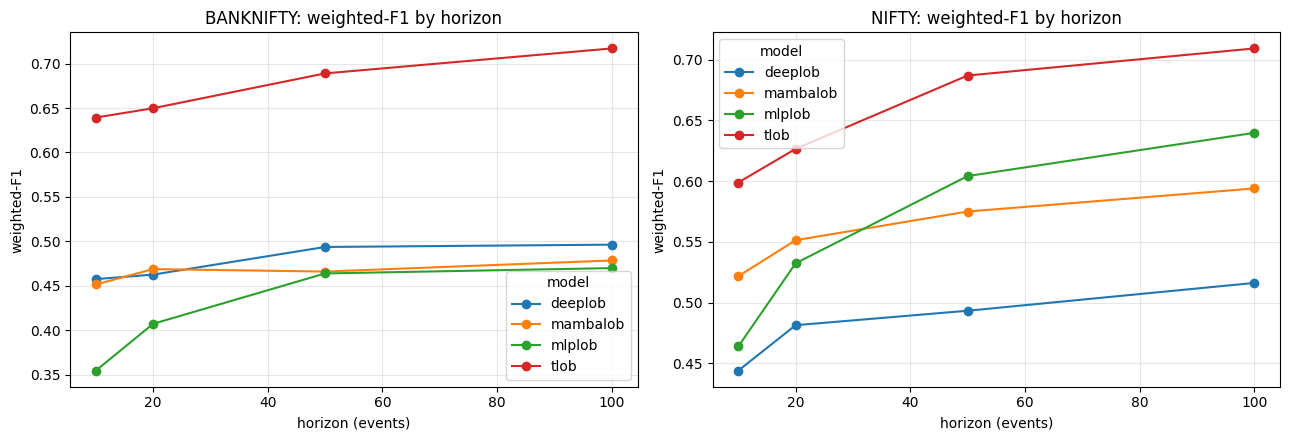

=== NSE Scheme A — weighted-F1 (model x horizon) ===
model              deeplob  mambalob  mlplob    tlob
symbol    horizon                                   
BANKNIFTY 10        0.4574    0.4514  0.3544  0.6393
          20        0.4625    0.4687  0.4071  0.6498
          50        0.4936    0.4659  0.4638  0.6890
          100       0.4962    0.4784  0.4698  0.7171
NIFTY     10        0.4440    0.5217  0.4639  0.5989
          20        0.4814    0.5514  0.5324  0.6266
          50        0.4933    0.5750  0.6042  0.6870
          100       0.5162    0.5940  0.6398  0.7093

=== Lift over best naive baseline (weighted-F1) ===
model              deeplob  mambalob  mlplob    tlob
symbol    horizon                                   
BANKNIFTY 10        0.1165    0.1105  0.0135  0.2984
          20        0.0811    0.0873  0.0257  0.2684
          50        0.0543    0.0266  0.0245  0.2497
          100       0.0332    0.0154  0.0068  0.2541
NIFTY     10        0.0947    0.1724  0.1146  

In [19]:
import matplotlib.pyplot as plt
res = pd.read_csv(RESULTS_CSV)
if "label_scheme" in res.columns:
    res = res[res.label_scheme == "A"].copy()
res["best_baseline_wf1"] = res[["baseline_majority_wf1", "baseline_stat_wf1", "baseline_random_wf1"]].max(axis=1)
res["lift_vs_baseline"] = (res["test_weighted_f1"] - res["best_baseline_wf1"]).round(4)

syms = sorted(res.symbol.unique())
fig, axes = plt.subplots(1, len(syms), figsize=(6.5 * len(syms), 4.5), squeeze=False)
for ax, sym in zip(axes[0], syms):
    res[res.symbol == sym].pivot_table(index="horizon", columns="model", values="test_weighted_f1").plot(marker="o", ax=ax)
    ax.set(title=f"{sym}: weighted-F1 by horizon", xlabel="horizon (events)", ylabel="weighted-F1")
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(RESULTS_DIR / "fig_nse_wf1_by_horizon.png", dpi=150, bbox_inches="tight"); plt.show()

print("=== NSE Scheme A — weighted-F1 (model x horizon) ===")
print(res.pivot_table(index=["symbol", "horizon"], columns="model", values="test_weighted_f1").round(4).to_string())
print("\n=== Lift over best naive baseline (weighted-F1) ===")
print(res.pivot_table(index=["symbol", "horizon"], columns="model", values="lift_vs_baseline").round(4).to_string())
s3_put(_s3, RESULTS_DIR / "fig_nse_wf1_by_horizon.png", S3_BUCKET, S3_PREFIX)

### Findings (Scheme A, NSE transfer)
- **TLOB leads** across horizons, mirroring FI-2010; **all models beat the naive baselines** (random ≈ 0.33) → there *is* learnable signal on NSE.
- **Absolute F1 is well below FI-2010** (TLOB ~0.6–0.7 vs ~0.88) — the expected **LOBCAST-style degradation on new data**; a finding, not a failure.
- Mamba's NSE accuracy vs the baselines is the headline novelty question (the FI-2010 efficiency win — linear scaling, 27× fewer params than TLOB — already holds).
- **Deferred to `nse_extras.ipynb` (next week):** Scheme B (spread-relative labels, E4), multi-seed bootstrap CIs, cost-aware backtest (E8).

## 9. Persist results + checkpoints (S3 / Drive)

In [20]:
import glob
S3_BUCKET, S3_PREFIX, S3_REGION = "lob-capstone-data", "reproduction/nse", "ap-south-2"
try:
    import boto3
    s3 = boto3.client("s3", region_name=S3_REGION)
    for f in glob.glob("results/*") + glob.glob("checkpoints/nse/*"):
        key = f"{S3_PREFIX}/{f}"; s3.upload_file(f, S3_BUCKET, key); print("uploaded", key)
    print(f"Done -> s3://{S3_BUCKET}/{S3_PREFIX}/")
except Exception as e:
    print("S3 upload skipped:", repr(e))
# Drive: from google.colab import drive; drive.mount("/content/drive"); import shutil
#        shutil.copytree("results", "/content/drive/MyDrive/nse_matrix/results", dirs_exist_ok=True)

uploaded reproduction/nse/results/fig_nse_wf1_by_horizon.png
uploaded reproduction/nse/results/nse_matrix.csv
uploaded reproduction/nse/checkpoints/nse/mambalob_NIFTY_h10_s0.pt
uploaded reproduction/nse/checkpoints/nse/tlob_NIFTY_h50_s0.pt
uploaded reproduction/nse/checkpoints/nse/tlob_BANKNIFTY_h10_s0.pt
uploaded reproduction/nse/checkpoints/nse/mambalob_NIFTY_h50_s0.pt
uploaded reproduction/nse/checkpoints/nse/mambalob_NIFTY_h20_s0.pt
uploaded reproduction/nse/checkpoints/nse/deeplob_NIFTY_h20_s0.pt
uploaded reproduction/nse/checkpoints/nse/deeplob_BANKNIFTY_h100_s0.pt
uploaded reproduction/nse/checkpoints/nse/mlplob_NIFTY_h20_s0.pt
uploaded reproduction/nse/checkpoints/nse/tlob_NIFTY_h20_s0.pt
uploaded reproduction/nse/checkpoints/nse/mlplob_NIFTY_h100_s0.pt
uploaded reproduction/nse/checkpoints/nse/deeplob_NIFTY_h10_s0.pt
uploaded reproduction/nse/checkpoints/nse/mlplob_NIFTY_h10_s0.pt
uploaded reproduction/nse/checkpoints/nse/mambalob_BANKNIFTY_h20_s0.pt
uploaded reproduction/nse/